# ST-FraudNet: 18-Module IEEE-CIS Fraud Detection Pipeline

This Colab notebook implements an organized research prototype containing:

- Temporal Transformer
- Historical transaction graph
- GraphSAGE
- Adaptive temporal–graph fusion
- Evaluation, threshold analysis, plots, and structured XAI evidence

> Upload `train_transaction.csv` and `train_identity.csv` when prompted. For a full thesis implementation, maintain strict `TransactionID` alignment between temporal and graph branches and use neighbor sampling for large graphs.


## Module 1 — Environment Setup and Imports

In [1]:
!pip -q install torch-geometric openpyxl

import os, gc, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import SAGEConv
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef, confusion_matrix,
    precision_recall_curve, roc_curve)
from IPython.display import display
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device:', device)
if torch.cuda.is_available(): print('GPU:', torch.cuda.get_device_name(0))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.6 MB/s eta 0:00:00
PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


## Module 2 — Reproducibility and Project Directories

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

BASE_DIR = '/content/ST_FraudNet'
DATA_DIR = os.path.join(BASE_DIR, 'data')
CSV_DIR = os.path.join(BASE_DIR, 'csv_outputs')
EXCEL_DIR = os.path.join(BASE_DIR, 'excel_outputs')
MODEL_DIR = os.path.join(BASE_DIR, 'models')
PLOT_DIR = os.path.join(BASE_DIR, 'plots')
GRAPH_DIR = os.path.join(BASE_DIR, 'graphs')
for d in [BASE_DIR, DATA_DIR, CSV_DIR, EXCEL_DIR, MODEL_DIR, PLOT_DIR, GRAPH_DIR]: os.makedirs(d, exist_ok=True)
print('Seed:', SEED)
print('Output directory:', BASE_DIR)


Seed: 42
Output directory: /content/ST_FraudNet


## Module 3 — Dataset Location and Loading

In [3]:
from google.colab import files

TRANSACTION_PATH = '/content/train_transaction.csv'
IDENTITY_PATH = '/content/train_identity.csv'

missing = [p for p in [TRANSACTION_PATH, IDENTITY_PATH] if not os.path.exists(p)]
if missing:
    print('Upload the missing files:', [os.path.basename(p) for p in missing])
    uploaded = files.upload()
    for name in uploaded:
        if name == 'train_transaction.csv': TRANSACTION_PATH = '/content/' + name
        if name == 'train_identity.csv': IDENTITY_PATH = '/content/' + name

assert os.path.exists(TRANSACTION_PATH), 'train_transaction.csv was not found.'
assert os.path.exists(IDENTITY_PATH), 'train_identity.csv was not found.'
train_transaction = pd.read_csv(TRANSACTION_PATH)
train_identity = pd.read_csv(IDENTITY_PATH)
print('Transaction shape:', train_transaction.shape)
print('Identity shape:', train_identity.shape)


Upload the missing files: ['train_transaction.csv', 'train_identity.csv']


Saving train_identity.csv to train_identity.csv
Saving train_transaction.csv to train_transaction.csv
Transaction shape: (590540, 394)
Identity shape: (144233, 41)


## Module 4 — Data Merging and Quality Analysis

In [4]:
df = train_transaction.merge(train_identity, on='TransactionID', how='left')
df = df.sort_values('TransactionID').reset_index(drop=True)
df['time_index'] = np.arange(len(df))
print('Merged shape:', df.shape)
display(df.head())

quality_summary = pd.DataFrame({
    'Metric': ['Transaction rows', 'Identity rows', 'Merged rows', 'Merged columns', 'Duplicate rows'],
    'Value': [len(train_transaction), len(train_identity), len(df), df.shape[1], int(df.duplicated().sum())]
})
display(quality_summary)
quality_summary.to_csv(os.path.join(CSV_DIR, 'module_04_quality_summary.csv'), index=False)


Merged shape: (590540, 435)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,time_index
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,4


,Metric,Value
0,Transaction rows,590540
1,Identity rows,144233
2,Merged rows,590540
3,Merged columns,435
4,Duplicate rows,0


## Module 5 — Target Distribution and Class Imbalance

In [5]:
target_counts = df['isFraud'].value_counts().sort_index()
target_summary = pd.DataFrame({'Class': target_counts.index, 'Count': target_counts.values})
target_summary['Percentage'] = target_summary['Count'] / len(df) * 100
display(target_summary)
target_summary.to_csv(os.path.join(CSV_DIR, 'module_05_target_distribution.csv'), index=False)


,Class,Count,Percentage
0,0,569877,96.500999
1,1,20663,3.499001


## Module 6 — Chronological Train/Validation/Test Split

In [6]:
n = len(df)
train_end, val_end = int(n * .70), int(n * .85)
train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

split_summary = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Rows': [len(train_df), len(val_df), len(test_df)],
    'Fraud_Count': [int(train_df.isFraud.sum()), int(val_df.isFraud.sum()), int(test_df.isFraud.sum())]
})
split_summary['Fraud_Rate_Percent'] = split_summary['Fraud_Count'] / split_summary['Rows'] * 100
display(split_summary)
split_summary.to_csv(os.path.join(CSV_DIR, 'module_06_temporal_split.csv'), index=False)


,Split,Rows,Fraud_Count,Fraud_Rate_Percent
0,Train,413378,14538,3.516878
1,Validation,88581,3042,3.434145
2,Test,88581,3083,3.480430


## Module 7 — Feature Selection

In [7]:
NUMERIC_FEATURES = ['TransactionAmt','card1','card2','card3','card5','addr1','addr2','dist1','dist2'] + [f'C{i}' for i in range(1,15)] + [f'D{i}' for i in range(1,16)]
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in df.columns]
GRAPH_RELATIONS = [c for c in ['card1','card2','card3','card5','addr1','addr2','P_emaildomain','R_emaildomain','DeviceInfo'] if c in df.columns]
print('Numeric features:', len(NUMERIC_FEATURES), NUMERIC_FEATURES)
print('Graph relations:', GRAPH_RELATIONS)
assert NUMERIC_FEATURES, 'No selected numeric features were found.'


Numeric features: 38 ['TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15']
Graph relations: ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'DeviceInfo']


## Module 8 — Numeric Preprocessing

In [8]:
train_features = train_df[NUMERIC_FEATURES].apply(pd.to_numeric, errors='coerce').astype('float32')
val_features = val_df[NUMERIC_FEATURES].apply(pd.to_numeric, errors='coerce').astype('float32')
test_features = test_df[NUMERIC_FEATURES].apply(pd.to_numeric, errors='coerce').astype('float32')
train_medians = train_features.median()
train_features = train_features.fillna(train_medians)
val_features = val_features.fillna(train_medians)
test_features = test_features.fillna(train_medians)
train_mean, train_std = train_features.mean(), train_features.std().replace(0, 1)
X_train = ((train_features - train_mean) / train_std).values.astype('float32')
X_val = ((val_features - train_mean) / train_std).values.astype('float32')
X_test = ((test_features - train_mean) / train_std).values.astype('float32')
preprocessing_summary = pd.DataFrame({'Feature': NUMERIC_FEATURES, 'Training_Mean': train_mean.values, 'Training_Std': train_std.values, 'Training_Median': train_medians.values})
preprocessing_summary.to_csv(os.path.join(CSV_DIR, 'module_08_preprocessing.csv'), index=False)
print(X_train.shape, X_val.shape, X_test.shape)


(413378, 38) (88581, 38) (88581, 38)


## Module 9 — Temporal Sequence Generation

In [9]:
SEQUENCE_LENGTH = 10
y_train = train_df.isFraud.values.astype('float32')
y_val = val_df.isFraud.values.astype('float32')
y_test = test_df.isFraud.values.astype('float32')

def create_sequences(X, y, sequence_length):
    if len(X) <= sequence_length: return np.empty((0, sequence_length, X.shape[1]), dtype='float32'), np.empty((0,), dtype='float32')
    return (np.asarray([X[i-sequence_length:i] for i in range(sequence_length, len(X))], dtype='float32'),
            np.asarray([y[i] for i in range(sequence_length, len(X))], dtype='float32'))

X_train_seq, y_train_seq = create_sequences(X_train, y_train, SEQUENCE_LENGTH)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, SEQUENCE_LENGTH)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, SEQUENCE_LENGTH)
print('Sequences:', X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)


Sequences: (413368, 10, 38) (88571, 10, 38) (88571, 10, 38)


## Module 10 — Temporal Transformer

In [10]:
class TemporalTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, n_heads=4, num_layers=2, dropout=.2):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, d_model)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dropout=dropout, batch_first=True, activation='gelu')
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.classifier = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1))
    def forward(self, x):
        x = self.transformer(self.input_projection(x))
        embedding = x[:, -1, :]
        return self.classifier(embedding).squeeze(-1), embedding


## Module 11 — PyTorch DataLoaders and Evaluation

In [11]:
class FraudSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32); self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

BATCH_SIZE = 256
train_loader = DataLoader(FraudSequenceDataset(X_train_seq, y_train_seq), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(FraudSequenceDataset(X_val_seq, y_val_seq), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(FraudSequenceDataset(X_test_seq, y_test_seq), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

def evaluate_predictions(y_true, y_probability, threshold=.5):
    y_true, y_probability = np.asarray(y_true), np.asarray(y_probability)
    y_pred = (y_probability >= threshold).astype(int)
    metrics = {'PR_AUC': average_precision_score(y_true, y_probability), 'ROC_AUC': roc_auc_score(y_true, y_probability), 'Precision': precision_score(y_true, y_pred, zero_division=0), 'Recall': recall_score(y_true, y_pred, zero_division=0), 'F1': f1_score(y_true, y_pred, zero_division=0), 'MCC': matthews_corrcoef(y_true, y_pred)}
    return metrics, y_pred


## Module 12 — Train and Evaluate Temporal Transformer

In [12]:
def collect_transformer_outputs(model, loader):
    model.eval(); probs, labels, embeddings = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits, emb = model(xb.to(device))
            probs.extend(torch.sigmoid(logits).cpu().numpy()); labels.extend(yb.numpy()); embeddings.append(emb.cpu())
    return np.asarray(labels), np.asarray(probs), torch.cat(embeddings).numpy()

pos_weight_value = float((y_train_seq == 0).sum() / max((y_train_seq == 1).sum(), 1))
transformer_model = TemporalTransformer(X_train_seq.shape[-1]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight_value, device=device))
optimizer = torch.optim.AdamW(transformer_model.parameters(), lr=1e-3, weight_decay=1e-4)
EPOCHS = 10
training_history = []
for epoch in range(EPOCHS):
    transformer_model.train(); total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device); optimizer.zero_grad()
        logits, _ = transformer_model(xb); loss = criterion(logits, yb); loss.backward(); optimizer.step(); total_loss += loss.item()
    avg_loss = total_loss / max(len(train_loader), 1); training_history.append({'Epoch': epoch+1, 'Training_Loss': avg_loss}); print(f'Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}')

transformer_labels, transformer_probabilities, transformer_embeddings = collect_transformer_outputs(transformer_model, test_loader)
transformer_metrics, transformer_predictions = evaluate_predictions(transformer_labels, transformer_probabilities)
print(transformer_metrics)
pd.DataFrame([{'Model':'Temporal Transformer', **transformer_metrics}]).to_csv(os.path.join(CSV_DIR, 'module_12_transformer_metrics.csv'), index=False)
pd.DataFrame(training_history).to_csv(os.path.join(CSV_DIR, 'module_12_transformer_history.csv'), index=False)
pd.DataFrame({'True_Label':transformer_labels, 'Predicted_Probability':transformer_probabilities, 'Predicted_Label':transformer_predictions}).to_csv(os.path.join(CSV_DIR, 'module_12_transformer_predictions.csv'), index=False)
torch.save(transformer_model.state_dict(), os.path.join(MODEL_DIR, 'temporal_transformer.pt'))


Epoch 1/10 - Loss: 1.3277
Epoch 2/10 - Loss: 1.3255
Epoch 3/10 - Loss: 1.3241
Epoch 4/10 - Loss: 1.3212
Epoch 5/10 - Loss: 1.3186
Epoch 6/10 - Loss: 1.3195
Epoch 7/10 - Loss: 1.3179
Epoch 8/10 - Loss: 1.3163
Epoch 9/10 - Loss: 1.3159
Epoch 10/10 - Loss: 1.3152
{'PR_AUC': np.float64(0.05277499941524501), 'ROC_AUC': np.float64(0.5558647716228818), 'Precision': 0.04257907542579075, 'Recall': 0.4654557249432371, 'F1': 0.0780209324452902, 'MCC': np.float64(0.03322650240617197)}


## Module 13 — Historical Graph Construction

In [13]:
GRAPH_SAMPLE_SIZE = min(50000, len(df))
graph_df = df.iloc[:GRAPH_SAMPLE_SIZE].copy()

def build_historical_edges(data, relation_columns, max_neighbors_per_relation=3):
    edges, history = [], {c:{} for c in relation_columns}
    for current_idx, row in data.reset_index(drop=True).iterrows():
        for col in relation_columns:
            value = row[col]
            if pd.isna(value): continue
            value = str(value); previous = history[col].setdefault(value, [])
            for previous_idx in previous[-max_neighbors_per_relation:]: edges.append([previous_idx, current_idx])
            previous.append(current_idx)
    if not edges: return torch.empty((2,0), dtype=torch.long)
    return torch.tensor(edges, dtype=torch.long).t().contiguous()

edge_index = build_historical_edges(graph_df, GRAPH_RELATIONS, 3)
torch.save(edge_index, os.path.join(GRAPH_DIR, 'historical_edge_index.pt'))
pd.DataFrame({'Metric':['Nodes','Edges','Relations'], 'Value':[len(graph_df), edge_index.shape[1], len(GRAPH_RELATIONS)]}).to_csv(os.path.join(CSV_DIR, 'module_13_graph_summary.csv'), index=False)
print('Nodes:', len(graph_df), 'Edges:', edge_index.shape[1])


Nodes: 50000 Edges: 1049942


## Module 14 — Graph Node Features and GraphSAGE

In [14]:
class GraphSAGEFraudModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout=.2):
        super().__init__()
        self.conv1 = SAGEConv(input_dim, hidden_dim); self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.classifier = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1))
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index)); embedding = F.relu(self.conv2(x, edge_index))
        return self.classifier(embedding).squeeze(-1), embedding

graph_numeric = graph_df[NUMERIC_FEATURES].apply(pd.to_numeric, errors='coerce').astype('float32')
graph_numeric = graph_numeric.fillna(graph_numeric.median())
graph_x = torch.tensor(graph_numeric.values, dtype=torch.float32, device=device)
graph_y = torch.tensor(graph_df.isFraud.values, dtype=torch.float32, device=device)
edge_index = edge_index.to(device)
print(graph_x.shape, graph_y.shape, edge_index.shape)


torch.Size([50000, 38]) torch.Size([50000]) torch.Size([2, 1049942])


## Module 15 — Train and Evaluate GraphSAGE

In [15]:
graph_model = GraphSAGEFraudModel(graph_x.shape[1]).to(device)
graph_pos_weight = ((graph_y == 0).sum() / torch.clamp((graph_y == 1).sum(), min=1)).float()
criterion_graph = nn.BCEWithLogitsLoss(pos_weight=graph_pos_weight)
optimizer_graph = torch.optim.AdamW(graph_model.parameters(), lr=1e-3, weight_decay=1e-4)
graph_history = []
for epoch in range(EPOCHS):
    graph_model.train(); optimizer_graph.zero_grad(); logits, graph_embeddings = graph_model(graph_x, edge_index)
    loss = criterion_graph(logits, graph_y); loss.backward(); optimizer_graph.step()
    graph_history.append({'Epoch':epoch+1,'Training_Loss':loss.item()}); print(f'Epoch {epoch+1}/{EPOCHS} - Loss: {loss.item():.4f}')

graph_model.eval()
with torch.no_grad():
    graph_logits, graph_embeddings = graph_model(graph_x, edge_index); graph_probabilities = torch.sigmoid(graph_logits).cpu().numpy()
graph_labels = graph_y.cpu().numpy(); graph_metrics, graph_predictions = evaluate_predictions(graph_labels, graph_probabilities)
print(graph_metrics)
pd.DataFrame([{'Model':'GraphSAGE', **graph_metrics}]).to_csv(os.path.join(CSV_DIR, 'module_15_graphsage_metrics.csv'), index=False)
pd.DataFrame(graph_history).to_csv(os.path.join(CSV_DIR, 'module_15_graphsage_history.csv'), index=False)
torch.save(graph_model.state_dict(), os.path.join(MODEL_DIR, 'graphsage.pt'))


Epoch 1/10 - Loss: 46.5017
Epoch 2/10 - Loss: 65.3832
Epoch 3/10 - Loss: 44.4986
Epoch 4/10 - Loss: 34.7140
Epoch 5/10 - Loss: 40.4467
Epoch 6/10 - Loss: 39.0983
Epoch 7/10 - Loss: 28.6366
Epoch 8/10 - Loss: 24.1763
Epoch 9/10 - Loss: 26.3961
Epoch 10/10 - Loss: 24.3850
{'PR_AUC': np.float64(0.03263235756008347), 'ROC_AUC': np.float64(0.5294825135610082), 'Precision': 0.026812398599607205, 'Recall': 0.9255711127487104, 'F1': 0.05211510134644509, 'MCC': np.float64(-0.007767372678607053)}


## Module 16 — Adaptive Fusion and Proposed ST-FraudNet

In [16]:
class AdaptiveFusion(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(embedding_dim*2, embedding_dim), nn.ReLU(), nn.Linear(embedding_dim, 1))
    def forward(self, temporal_embedding, graph_embedding):
        alpha = torch.sigmoid(self.gate(torch.cat([temporal_embedding, graph_embedding], dim=1)))
        fused = alpha * temporal_embedding + (1-alpha) * graph_embedding
        return fused, alpha

class STFRAUDNet(nn.Module):
    def __init__(self, temporal_dim, graph_dim, hidden_dim=64):
        super().__init__()
        self.temporal_projection = nn.Linear(temporal_dim, hidden_dim)
        self.graph_projection = nn.Linear(graph_dim, hidden_dim)
        self.fusion = AdaptiveFusion(hidden_dim)
        self.classifier = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Dropout(.2), nn.Linear(32, 1))
    def forward(self, temporal_embedding, graph_embedding):
        t = self.temporal_projection(temporal_embedding); g = self.graph_projection(graph_embedding)
        fused, alpha = self.fusion(t, g); return self.classifier(fused).squeeze(-1), fused, alpha

print('Fusion architecture defined.')
print('For final training, align temporal and graph embeddings by TransactionID before calling STFRAUDNet.')


Fusion architecture defined.
For final training, align temporal and graph embeddings by TransactionID before calling STFRAUDNet.


## Module 17 — Model Comparison and Visualizations

,Model,PR_AUC,ROC_AUC,Precision,Recall,F1,MCC
0,Temporal Transformer,0.052775,0.555865,0.042579,0.465456,0.078021,0.033227
1,GraphSAGE,0.032632,0.529483,0.026812,0.925571,0.052115,-0.007767


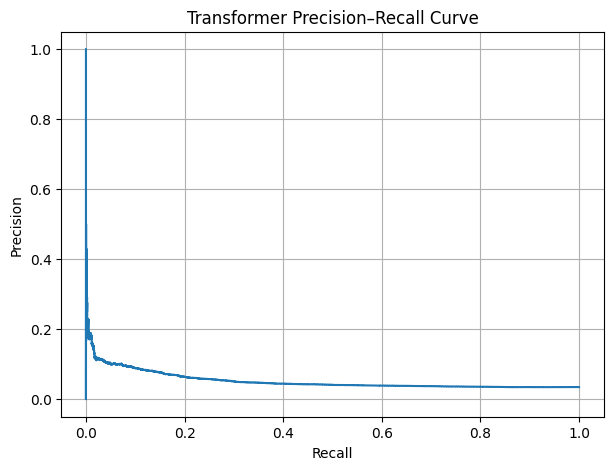

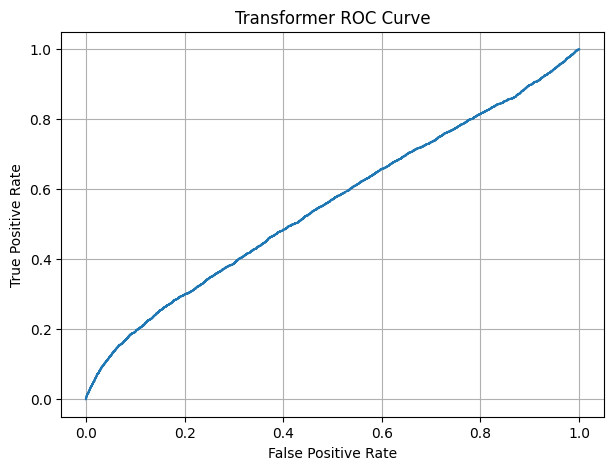

,Threshold,PR_AUC,ROC_AUC,Precision,Recall,F1,MCC
0,0.10,0.052775,0.555865,0.034808,1.000000,0.067275,0.000000
1,0.15,0.052775,0.555865,0.034808,1.000000,0.067275,0.000000
2,0.20,0.052775,0.555865,0.034808,1.000000,0.067275,0.000000
3,0.25,0.052775,0.555865,0.034808,1.000000,0.067275,0.000000
4,0.30,0.052775,0.555865,0.034808,1.000000,0.067275,0.000000
5,0.35,0.052775,0.555865,0.034808,1.000000,0.067275,0.000000
6,0.40,0.052775,0.555865,0.034808,1.000000,0.067275,0.000000
7,0.45,0.052775,0.555865,0.034798,0.999027,0.067253,-0.002259
8,0.50,0.052775,0.555865,0.042579,0.465456,0.078021,0.033227
9,0.55,0.052775,0.555865,0.069656,0.173857,0.099462,0.058643


In [17]:
comparison_df = pd.DataFrame([
    {'Model':'Temporal Transformer', **transformer_metrics},
    {'Model':'GraphSAGE', **graph_metrics}
])
display(comparison_df)
comparison_df.to_csv(os.path.join(CSV_DIR, 'module_17_model_comparison.csv'), index=False)

# Transformer confusion matrix
cm = confusion_matrix(transformer_labels, transformer_predictions)
pd.DataFrame(cm, index=['Actual_0','Actual_1'], columns=['Predicted_0','Predicted_1']).to_csv(os.path.join(CSV_DIR, 'module_17_transformer_confusion_matrix.csv'))

precision_curve, recall_curve, _ = precision_recall_curve(transformer_labels, transformer_probabilities)
plt.figure(figsize=(7,5)); plt.plot(recall_curve, precision_curve); plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Transformer Precision–Recall Curve'); plt.grid(True); plt.savefig(os.path.join(PLOT_DIR, 'transformer_pr_curve.png'), dpi=200, bbox_inches='tight'); plt.show()

fpr, tpr, _ = roc_curve(transformer_labels, transformer_probabilities)
plt.figure(figsize=(7,5)); plt.plot(fpr, tpr); plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('Transformer ROC Curve'); plt.grid(True); plt.savefig(os.path.join(PLOT_DIR, 'transformer_roc_curve.png'), dpi=200, bbox_inches='tight'); plt.show()

threshold_results=[]
for threshold in np.arange(.10, .91, .05):
    metrics, _ = evaluate_predictions(transformer_labels, transformer_probabilities, threshold)
    threshold_results.append({'Threshold':round(float(threshold),2), **metrics})
threshold_df=pd.DataFrame(threshold_results); display(threshold_df); threshold_df.to_csv(os.path.join(CSV_DIR,'module_17_threshold_analysis.csv'), index=False)


## Module 18 — XAI Evidence, LLM Input, and Excel Report

In [18]:
def create_explanation_evidence(transaction_id, fraud_probability, threshold=.5, temporal_weight=None, top_features=None):
    return {'TransactionID': transaction_id, 'Model_Probability': float(fraud_probability), 'Decision': 'Fraud' if fraud_probability >= threshold else 'Legitimate', 'Threshold': threshold, 'Temporal_Weight': None if temporal_weight is None else float(temporal_weight), 'Top_Features': top_features or []}

evidence = [create_explanation_evidence(i, p) for i, p in enumerate(transformer_probabilities[:100])]
evidence_df = pd.DataFrame(evidence); evidence_df.to_csv(os.path.join(CSV_DIR, 'module_18_explanation_evidence.csv'), index=False)

master_excel_path = os.path.join(EXCEL_DIR, 'ST_FraudNet_Research_Results.xlsx')
with pd.ExcelWriter(master_excel_path, engine='openpyxl') as writer:
    quality_summary.to_excel(writer, sheet_name='Data_Quality', index=False)
    target_summary.to_excel(writer, sheet_name='Target_Distribution', index=False)
    split_summary.to_excel(writer, sheet_name='Temporal_Split', index=False)
    preprocessing_summary.to_excel(writer, sheet_name='Preprocessing', index=False)
    comparison_df.to_excel(writer, sheet_name='Model_Comparison', index=False)
    threshold_df.to_excel(writer, sheet_name='Thresholds', index=False)
    evidence_df.to_excel(writer, sheet_name='XAI_Evidence', index=False)
print('Excel workbook:', master_excel_path)

# Example evidence format for an LLM:
print(evidence[0])


Excel workbook: /content/ST_FraudNet/excel_outputs/ST_FraudNet_Research_Results.xlsx
{'TransactionID': 0, 'Model_Probability': 0.6013988852500916, 'Decision': 'Fraud', 'Threshold': 0.5, 'Temporal_Weight': None, 'Top_Features': []}


## Recommended Research Extensions

1. Align temporal and graph embeddings by `TransactionID`.
2. Use historical context across split boundaries instead of independently restarting every sequence.
3. Replace the development graph with scalable neighbor sampling.
4. Add categorical embeddings and compare GraphSAGE with GATv2.
5. Add ablation experiments for the adaptive gate.
6. Use SHAP or another attribution method to populate `Top_Features`.
7. Evaluate explanation faithfulness separately from fraud-classification performance.
